# Week 1: Linear Regression and Logistic Regression

In [2]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris, fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (mean_squared_error, r2_score,
                             classification_report, ConfusionMatrixDisplay)

housing = fetch_california_housing(as_frame=True).frame
iris = load_iris(as_frame=True).frame


In [3]:
X = housing.drop(columns="MedHouseVal")
y = housing["MedHouseVal"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lr = LinearRegression().fit(X_train, y_train)
pred = lr.predict(X_test)

print("MSE:", mean_squared_error(y_test, pred))
print("R2:", r2_score(y_test, pred))

MSE: 0.5558915986952442
R2: 0.575787706032451


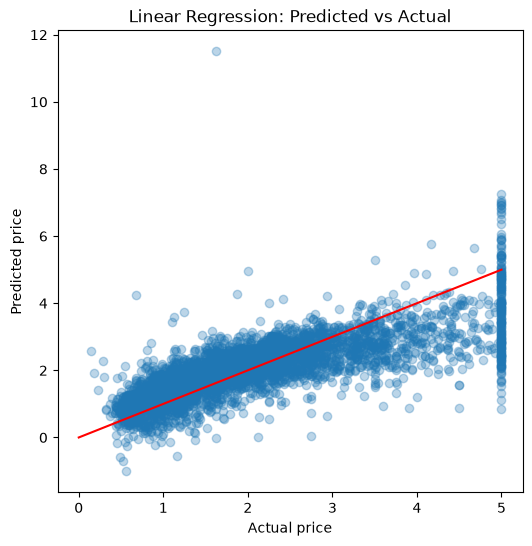

In [4]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, pred, alpha=0.3)
plt.plot([0, 5], [0, 5], color="red")
plt.xlabel("Actual price")
plt.ylabel("Predicted price")
plt.title("Linear Regression: Predicted vs Actual")
plt.show()

### Linear Regression: Observations
- Model: LinearRegression on 8 features, 80/20 train/test split.
- R² = 0.58 means the model explains about 58% of the variation in house prices.
- In the plot, points are scattered around the red line, and there is a flat band at the top because prices are capped at 5.0.

## Part 2: Logistic Regression (Iris)

In [5]:
Xi = iris.drop(columns="target")
yi = iris["target"]
Xi_tr, Xi_te, yi_tr, yi_te = train_test_split(Xi, yi, test_size=0.2, random_state=42, stratify=yi)

clf = LogisticRegression(max_iter=200).fit(Xi_tr, yi_tr)
yp = clf.predict(Xi_te)

print(classification_report(yi_te, yp))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.90      0.95        10
           2       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



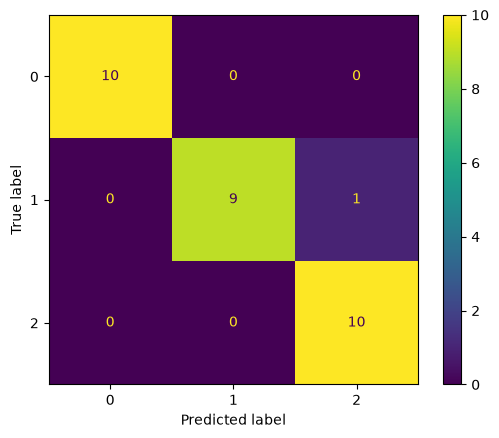

In [6]:
ConfusionMatrixDisplay.from_predictions(yi_te, yp)
plt.show()

### Logistic Regression: Observations
- Model: LogisticRegression on 4 Iris features, stratified 80/20 split (30 test samples).
- Accuracy = 0.97, macro-average precision, recall and F1 = 0.97.
- Setosa (class 0) is classified perfectly (precision, recall, F1 = 1.00) because it is clearly separated from the other classes.
- Only one mistake: one class 1 (versicolor) sample was predicted as class 2 (virginica). This is why class 1 recall is 0.90 and class 2 precision is 0.91. These two classes overlap slightly.
- Accuracy is a fair metric here because the classes are balanced.

## Part 3: Linear Regression with Gradient Descent (from scratch, NumPy)

In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
Xtr_s = scaler.fit_transform(X_train)
Xte_s = scaler.transform(X_test)
ytr = y_train.values

In [8]:
def gradient_descent(X, y, lr=0.1, epochs=200):
    m, n = X.shape
    w = np.zeros(n)
    b = 0.0
    costs = []
    for _ in range(epochs):
        pred = X @ w + b
        err = pred - y
        costs.append((err ** 2).mean() / 2)
        w -= lr * (X.T @ err) / m
        b -= lr * err.mean()
    return w, b, costs

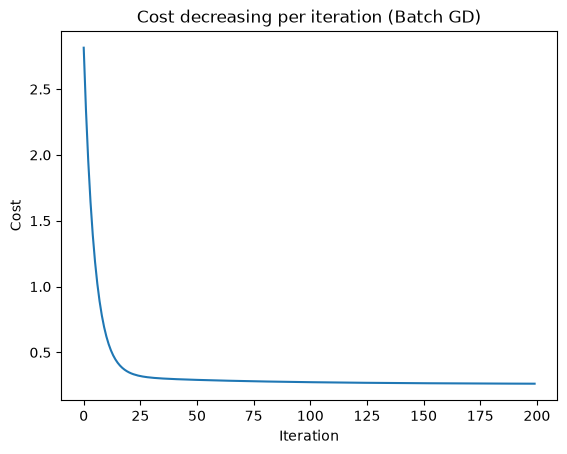

In [9]:
w, b, costs = gradient_descent(Xtr_s, ytr, lr=0.1, epochs=200)

plt.plot(costs)
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("Cost decreasing per iteration (Batch GD)")
plt.show()

In [10]:
pred_gd = Xte_s @ w + b
print("Scratch -> MSE:", mean_squared_error(y_test, pred_gd), "R2:", r2_score(y_test, pred_gd))

lr2 = LinearRegression().fit(Xtr_s, ytr)
pred_sk = lr2.predict(Xte_s)
print("sklearn -> MSE:", mean_squared_error(y_test, pred_sk), "R2:", r2_score(y_test, pred_sk))

Scratch -> MSE: 0.5545776067629031 R2: 0.5767904402582992
sklearn -> MSE: 0.5558915986952444 R2: 0.5757877060324508


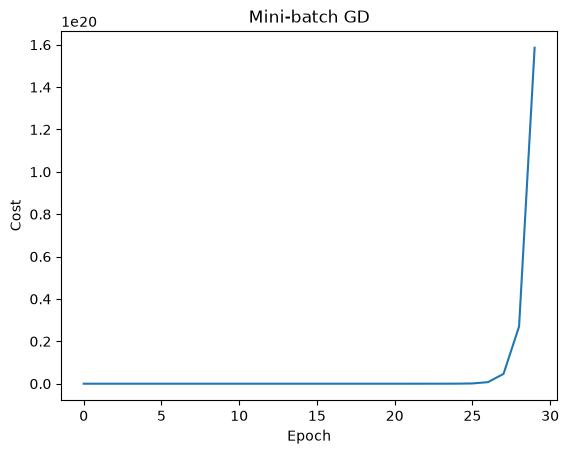

Mini-batch R2: -5.511612324560121e+18


In [11]:
def minibatch_gd(X, y, lr=0.05, epochs=30, batch_size=64):
    m, n = X.shape
    w = np.zeros(n)
    b = 0.0
    costs = []
    for _ in range(epochs):
        idx = np.random.permutation(m)
        for i in range(0, m, batch_size):
            batch = idx[i:i + batch_size]
            err = X[batch] @ w + b - y[batch]
            w -= lr * (X[batch].T @ err) / len(batch)
            b -= lr * err.mean()
        costs.append(((X @ w + b - y) ** 2).mean() / 2)
    return w, b, costs

w_mb, b_mb, costs_mb = minibatch_gd(Xtr_s, ytr)
plt.plot(costs_mb)
plt.xlabel("Epoch")
plt.ylabel("Cost")
plt.title("Mini-batch GD")
plt.show()
print("Mini-batch R2:", r2_score(y_test, Xte_s @ w_mb + b_mb))

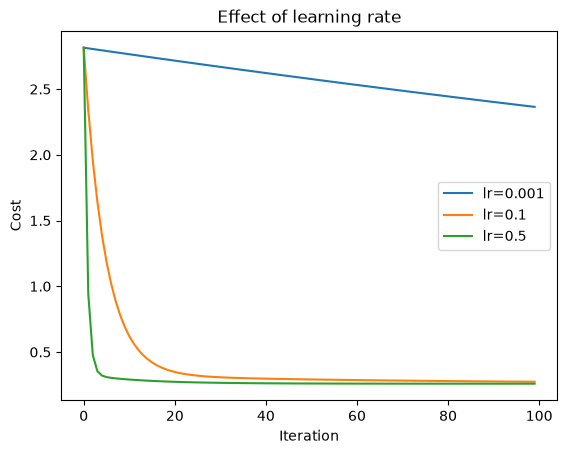

In [12]:
for lr_val in [0.001, 0.1, 0.5]:
    _, _, c = gradient_descent(Xtr_s, ytr, lr=lr_val, epochs=100)
    plt.plot(c, label=f"lr={lr_val}")
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.legend()
plt.title("Effect of learning rate")
plt.show()

### Gradient Descent: Observations
- Batch GD uses all samples for every step: smooth but slow on big data.
- Stochastic GD uses 1 sample per step: fast but noisy.
- Mini-batch GD uses small chunks: a balance of both, most commonly used.
- The cost curve decreases and flattens, which shows the model is learning.
- My scratch implementation gives MSE = (apna value) and R² = (apna value), almost the same as sklearn.
- Learning rate: too small is very slow, too large makes the cost jump or diverge.

## Part 4: Bias-Variance Tradeoff (Underfitting vs Overfitting)

In [13]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

rng = np.random.RandomState(0)
x = np.sort(rng.rand(60))[:, None]
y_poly = np.sin(2 * np.pi * x).ravel() + rng.randn(60) * 0.2

xp_tr, xp_te, yp_tr, yp_te = train_test_split(x, y_poly, test_size=0.3, random_state=1)

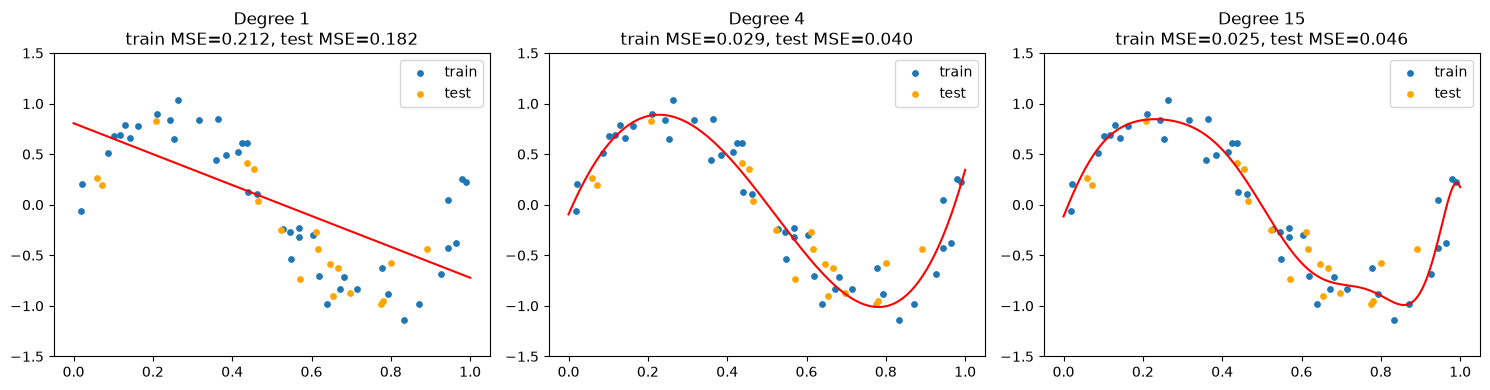

In [14]:
degrees = [1, 4, 15]
grid = np.linspace(0, 1, 200)[:, None]

plt.figure(figsize=(15, 4))
for i, d in enumerate(degrees):
    model = make_pipeline(PolynomialFeatures(d), LinearRegression()).fit(xp_tr, yp_tr)
    train_err = mean_squared_error(yp_tr, model.predict(xp_tr))
    test_err = mean_squared_error(yp_te, model.predict(xp_te))

    plt.subplot(1, 3, i + 1)
    plt.scatter(xp_tr, yp_tr, s=15, label="train")
    plt.scatter(xp_te, yp_te, s=15, color="orange", label="test")
    plt.plot(grid, model.predict(grid), color="red")
    plt.ylim(-1.5, 1.5)
    plt.title(f"Degree {d}\ntrain MSE={train_err:.3f}, test MSE={test_err:.3f}")
    plt.legend()
plt.tight_layout()
plt.show()

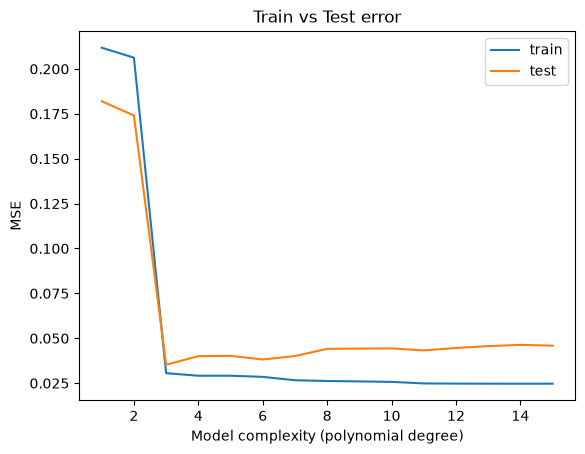

In [15]:
results = []
for d in range(1, 16):
    m = make_pipeline(PolynomialFeatures(d), LinearRegression()).fit(xp_tr, yp_tr)
    results.append((d, mean_squared_error(yp_tr, m.predict(xp_tr)),
                    mean_squared_error(yp_te, m.predict(xp_te))))

res = pd.DataFrame(results, columns=["degree", "train_mse", "test_mse"])
plt.plot(res["degree"], res["train_mse"], label="train")
plt.plot(res["degree"], res["test_mse"], label="test")
plt.xlabel("Model complexity (polynomial degree)")
plt.ylabel("MSE")
plt.legend()
plt.title("Train vs Test error")
plt.show()

### Bias-Variance: Observations
- **Underfitting (high bias):** Degree 1 and 2 are too simple to capture the sine curve, so both train and test error are high (about 0.18 to 0.21).
- **Good fit:** Degree 3 to 4 captures the curve, and both errors drop sharply (about 0.03 to 0.04).
- **Overfitting (high variance):** As the degree grows to 15, train error keeps decreasing (about 0.025) while test error stays higher and slightly rises (about 0.045). The growing gap between train and test error shows the model starts fitting the noise.
- As model complexity increases, bias decreases but variance increases. The best model is where test error is lowest (around degree 3 to 4 here).
- With more data or noise the overfitting would be much more visible. Ways to reduce overfitting: more data, simpler model, regularization, cross-validation.

## Part 5: Linear vs Logistic Regression (same binary data)

In [16]:
iris_bin = iris[iris["target"] != 2]
xb = iris_bin[["petal length (cm)"]].values
yb = iris_bin["target"].values

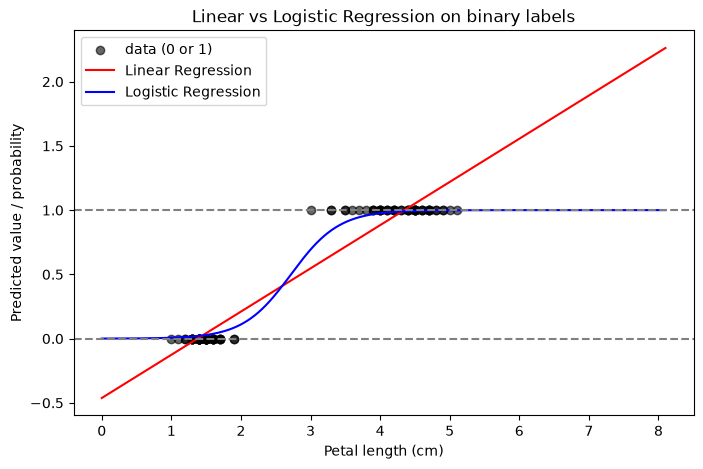

In [17]:
lin = LinearRegression().fit(xb, yb)
log = LogisticRegression().fit(xb, yb)

grid_b = np.linspace(xb.min() - 1, xb.max() + 3, 300).reshape(-1, 1)

plt.figure(figsize=(8, 5))
plt.scatter(xb, yb, color="black", alpha=0.6, label="data (0 or 1)")
plt.plot(grid_b, lin.predict(grid_b), color="red", label="Linear Regression")
plt.plot(grid_b, log.predict_proba(grid_b)[:, 1], color="blue", label="Logistic Regression")
plt.axhline(0, color="gray", linestyle="--")
plt.axhline(1, color="gray", linestyle="--")
plt.xlabel("Petal length (cm)")
plt.ylabel("Predicted value / probability")
plt.title("Linear vs Logistic Regression on binary labels")
plt.legend()
plt.show()

### Linear vs Logistic: Observations
- Linear regression fits a straight line, so on 0/1 labels its output goes below 0 and above 1, which cannot be a probability.
- Logistic regression applies the sigmoid function, so its output always stays between 0 and 1 and can be read as a class probability.
- Linear regression is used to predict continuous values (house price) and is evaluated with MSE and R².
- Logistic regression is used for classification (iris species) and is evaluated with accuracy, precision, recall and F1.
- This plot shows why logistic regression exists: a straight line is not suitable for classification.

| | Linear Regression | Logistic Regression |
|---|---|---|
| Predicts | Continuous number (house price) | Class probability (iris species) |
| Output range | Any real value | Between 0 and 1 (sigmoid) |
| Metrics | MSE, R² | Accuracy, precision, recall, F1 |
| Dataset used | California Housing | Iris |